# Scraping — Bonheur & Éducation par pays

**Objectif :** Constituer un dataset CSV labelisé, pays par pays, combinant :
- **Scores de bonheur** (World Happiness Report — `happiness_score` est le label cible ML)
- **Indices et métriques d'éducation** (Education Index HDI, alphabétisation, scolarisation)

**Pipeline :** Fetching → Parsing → Extracting → Transforming

| # | Source | Type | Données |
|---|--------|------|---------|
| 1 | Wikipedia — Education Index | HTML scraping | `education_index` (HDI, 0–1) |
| 2 | Wikipedia — World Happiness Report | HTML scraping | `happiness_score` + sous-composantes |
| 3 | Wikipedia — Literacy Rate | HTML scraping | `literacy_rate_pct` |
| 4 | **World Bank Open API** | JSON REST API | Dépenses éducation, scolarisation |
| 5 | Wikipedia — Tertiary Education | HTML scraping | `tertiary_attainment_pct` |
| 6 | **World Bank Open API** | JSON REST API | `gini_coefficient` (inégalités économiques) |
| 7 | **World Bank Open API** | JSON REST API | `pisa_score_avg` (qualité éducation, moy. maths/lecture/sciences) |

---
## 0. Setup

In [1]:
# !pip install requests beautifulsoup4 pandas numpy lxml

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
from io import StringIO

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
}

SESSION = requests.Session()
SESSION.headers.update(HEADERS)


def fetch_html(url: str, delay: float = 1.0) -> BeautifulSoup:
    """Fetche une URL HTML et retourne un BeautifulSoup."""
    time.sleep(delay)
    r = SESSION.get(url, timeout=15)
    r.raise_for_status()
    return BeautifulSoup(r.text, "lxml")


def fetch_json(url: str, delay: float = 0.5) -> dict:
    """Fetche une URL JSON et retourne le contenu parsé."""
    time.sleep(delay)
    r = SESSION.get(url, timeout=15)
    r.raise_for_status()
    return r.json()


def extract_wikitable(table_tag) -> pd.DataFrame:
    """Extrait un <table> Wikipedia en DataFrame (gère rowspan/colspan)."""
    return pd.read_html(StringIO(str(table_tag)), flavor="lxml")[0]


def clean_text(val) -> str:
    """Supprime annotations Wikipedia [n] et espaces superflus."""
    return re.sub(r"\[.*?\]", "", str(val)).strip()


def to_float(val) -> float:
    """Convertit en float, NaN si impossible."""
    try:
        return float(re.sub(r"[^\d.]", "", clean_text(val)))
    except (ValueError, TypeError):
        return np.nan


def normalize_country(name: str) -> str:
    """Standardise les noms de pays inter-sources.

    Couvre les variantes Wikipedia, World Bank et NationMaster.
    """
    name = clean_text(name)
    aliases = {
        # USA
        "United States": "United States",
        "USA": "United States",
        # UK
        "UK": "United Kingdom",
        # Russie
        "Russian Federation": "Russia",
        # Corée
        "Korea, South": "South Korea",
        "Korea, Rep.": "South Korea",
        "Republic of Korea": "South Korea",
        "Korea, North": "North Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Democratic People's Republic of Korea": "North Korea",
        # Congo
        "Congo, Dem. Rep.": "DR Congo",
        "Democratic Republic of the Congo": "DR Congo",
        "Congo, Rep.": "Republic of the Congo",
        # Iran
        "Iran, Islamic Rep.": "Iran",
        # Laos
        "Lao PDR": "Laos",
        # Kyrgyzstan
        "Kyrgyz Republic": "Kyrgyzstan",
        # Slovaquie
        "Slovak Republic": "Slovakia",
        # Tchéquie
        "Czechia": "Czech Republic",
        # Cap-Vert
        "Cabo Verde": "Cape Verde",
        # Eswatini
        "Eswatini": "Swaziland",
        # Macédoine
        "North Macedonia": "North Macedonia",
        # Vietnam
        "Viet Nam": "Vietnam",
        # Côte d'Ivoire
        "Côte d'Ivoire": "Ivory Coast",
        "Cote d'Ivoire": "Ivory Coast",
        # Yemen
        "Yemen, Rep.": "Yemen",
        # Egypte
        "Egypt, Arab Rep.": "Egypt",
        # Venezuela
        "Venezuela, RB": "Venezuela",
        # Turquie
        "Türkiye": "Turkey",
        "Turkiye": "Turkey",
        # Syrie
        "Syrian Arab Republic": "Syria",
        # Gambie
        "Gambia, The": "Gambia",
        # Bahamas
        "Bahamas, The": "Bahamas",
        # Micronésie
        "Micronesia, Fed. Sts.": "Micronesia",
        # Timor
        "Timor-Leste": "East Timor",
        # Brunei
        "Brunei Darussalam": "Brunei",
        # Saint-
        "St. Lucia": "Saint Lucia",
        "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
        "St. Kitts and Nevis": "Saint Kitts and Nevis",
        # Sao Tomé
        "Sao Tome and Principe": "São Tomé and Príncipe",
        # Palestine
        "West Bank and Gaza": "Palestine",
        # Happiness Report
        "Country or region": "",  # en-tête de colonne à ignorer
    }
    return aliases.get(name, name)


def make_join_key(name: str) -> str:
    """Clé de jointure insensible à la casse, aux accents et à la ponctuation.

    Absorbe les variantes typographiques entre sources sans alias exhaustif.
    Ex : 'Côte d\'Ivoire' == 'Cote d Ivoire', espaces multiples normalisés.
    """
    s = str(name).lower().strip()
    for char, repl in {
        "é": "e", "è": "e", "ê": "e", "ë": "e",
        "à": "a", "â": "a", "ä": "a", "á": "a",
        "î": "i", "ï": "i", "í": "i",
        "ô": "o", "ö": "o", "ó": "o",
        "û": "u", "ü": "u", "ú": "u",
        "ç": "c", "ñ": "n", "ß": "ss",
        "'": " ", "\u2019": " ", "-": " ", ",": " ", ".": "",
    }.items():
        s = s.replace(char, repl)
    return re.sub(r"\s+", " ", s).strip()


print("Setup OK")

Setup OK


---
## 1. Education Index — Wikipedia

**URL :** https://en.wikipedia.org/wiki/Education_Index  
Structure réelle : `Country | 1990 | 1991 | … | 2019` (colonnes = années, pas de label explicite)

In [3]:
# --- 1.1 Fetching ---
URL_EDU_INDEX = "https://en.wikipedia.org/wiki/Education_Index"
soup_edu = fetch_html(URL_EDU_INDEX)
print(f"Page : {soup_edu.title.text}")

Page : Education Index - Wikipedia


In [4]:
# --- 1.2 Parsing ---
tables_edu = soup_edu.find_all("table", class_="wikitable")
print(f"{len(tables_edu)} wikitable(s) trouvé(s)")
for i, t in enumerate(tables_edu):
    print(f"  [{i}] {[th.get_text(strip=True) for th in t.find_all('th')[:5]]}")

1 wikitable(s) trouvé(s)
  [0] ['Country', '2019', '2018', '2017', '2016']


In [5]:
# --- 1.3 Extracting ---
df_edu_raw = extract_wikitable(tables_edu[0])
print("Colonnes brutes :", df_edu_raw.columns.tolist())
df_edu_raw.head(3)

Colonnes brutes : ['Country', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007', '2006', '2005', '2004', '2003', '2002', '2001', '2000', '1999', '1998', '1997', '1996', '1995', '1994', '1993', '1992', '1991', '1990']


,Country,2019,2018,2017,2016,2015,2014,2013,2012,2011,...,1999,1998,1997,1996,1995,1994,1993,1992,1991,1990
0,Afghanistan,0.414,0.413,0.408,0.406,0.405,0.403,0.398,0.390,0.374,...,0.224,0.213,0.202,0.190,0.179,0.168,0.156,0.145,0.133,0.122
1,Albania,0.746,0.743,0.747,0.745,0.753,0.758,0.749,0.739,0.714,...,0.584,0.579,0.569,0.557,0.550,0.528,0.542,0.557,0.588,0.583
2,Algeria,0.672,0.668,0.665,0.660,0.659,0.652,0.639,0.639,0.644,...,0.487,0.473,0.458,0.443,0.431,0.424,0.414,0.405,0.395,0.385


In [6]:
# --- 1.4 Transforming ---
# Les colonnes sont des années (ex. 2019, 2018, …) → prendre la plus récente
col_country_edu = None
year_cols = []

for col in df_edu_raw.columns:
    s = str(col).strip()
    if "country" in s.lower() or "nation" in s.lower():
        col_country_edu = col
    elif re.match(r"^\d{4}$", s):
        year_cols.append(int(s))

if not col_country_edu:
    raise ValueError("Colonne pays introuvable dans Education Index")
if not year_cols:
    raise ValueError("Aucune colonne-année trouvée — vérifier la structure du tableau")

best_year = str(max(year_cols))
print(f"Années disponibles (5 plus récentes) : {sorted(year_cols, reverse=True)[:5]}")
print(f"→ Colonne retenue : '{best_year}'")

df_edu = pd.DataFrame({
    "country": df_edu_raw[col_country_edu].apply(normalize_country),
    "education_index": df_edu_raw[best_year].apply(to_float),
})
df_edu = df_edu[df_edu["country"].str.strip() != ""].dropna().reset_index(drop=True)

print(f"\nEducation Index : {len(df_edu)} pays")
df_edu.head(5)

Années disponibles (5 plus récentes) : [2019, 2018, 2017, 2016, 2015]
→ Colonne retenue : '2019'

Education Index : 189 pays


,country,education_index
0,Afghanistan,0.414
1,Albania,0.746
2,Algeria,0.672
3,Andorra,0.720
4,Angola,0.500


---
## 2. World Happiness Report — Wikipedia

**URL :** https://en.wikipedia.org/wiki/World_Happiness_Report  
Structure : `Overall rank | Country or region | Score | Log GDP | Social support | …`  
On capture toutes les sous-composantes (utiles comme features ML).

In [7]:
# --- 2.1 Fetching ---
URL_HAPPINESS = "https://en.wikipedia.org/wiki/World_Happiness_Report"
soup_happy = fetch_html(URL_HAPPINESS)
print(f"Page : {soup_happy.title.text}")

Page : World Happiness Report - Wikipedia


In [8]:
# --- 2.2 Parsing — sélection du tableau le plus récent avec scores ---
tables_happy = soup_happy.find_all("table", class_="wikitable")
print(f"{len(tables_happy)} wikitable(s)")

def score_happiness_table(tbl) -> int:
    """Score un tableau selon la présence de mots-clés happiness dans ses en-têtes."""
    text = " ".join(th.get_text(strip=True).lower() for th in tbl.find_all("th"))
    return (
        ("score" in text) * 4
        + ("country" in text) * 2
        + ("rank" in text) * 1
        + ("gdp" in text) * 2       # sous-composantes = table plus riche
        + ("support" in text) * 1
    )

best_tbl = max(tables_happy, key=score_happiness_table)
best_score = score_happiness_table(best_tbl)
print(f"Tableau retenu (score={best_score}) :",
      [th.get_text(strip=True) for th in best_tbl.find_all("th")[:6]])

12 wikitable(s)
Tableau retenu (score=10) : ['Overall rank', 'Country or region', 'Score', 'Log GDP per capita', 'Social support', 'Healthy life expectancy']


In [9]:
# --- 2.3 Extracting ---
df_happy_raw = extract_wikitable(best_tbl)
print("Colonnes brutes :", df_happy_raw.columns.tolist())
df_happy_raw.head(3)

Colonnes brutes : ['Overall rank', 'Country or region', 'Score', 'Log GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Dystopia + residual']


,Overall rank,Country or region,Score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,1,Finland,7.736,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2,Denmark,7.521,1.825,1.748,0.820,0.955,0.150,0.488,1.535
2,3,Iceland,7.515,1.799,1.840,0.873,0.971,0.201,0.173,1.659


In [10]:
# --- 2.4 Transforming ---
# Mapping automatique de toutes les colonnes connues
HAPPY_COL_PATTERNS = {
    "country":              lambda c: "country" in c or "nation" in c or "region" in c,
    "happiness_score":      lambda c: "score" in c or "ladder" in c,
    "rank_happiness":       lambda c: "rank" in c or "overall" in c,
    "gdp_per_capita_log":   lambda c: "gdp" in c,
    "social_support":       lambda c: "social" in c or "support" in c,
    "healthy_life_exp":     lambda c: "health" in c or "life" in c or "expectancy" in c,
    "freedom_choices":      lambda c: "freedom" in c,
    "generosity":           lambda c: "generosity" in c,
    "corruption_perception":lambda c: "corrupt" in c,
}

col_map_happy = {}
for col in df_happy_raw.columns:
    c_lower = str(col).lower()
    for key, match_fn in HAPPY_COL_PATTERNS.items():
        if key not in col_map_happy and match_fn(c_lower):
            col_map_happy[key] = col
            break

print("Mapping colonnes :", col_map_happy)

if "country" not in col_map_happy or "happiness_score" not in col_map_happy:
    raise ValueError(f"Colonnes obligatoires manquantes. Colonnes brutes : {df_happy_raw.columns.tolist()}")

df_happy = pd.DataFrame()
df_happy["country"] = df_happy_raw[col_map_happy["country"]].apply(normalize_country)

for feat, col in col_map_happy.items():
    if feat == "country":
        continue
    df_happy[feat] = df_happy_raw[col].apply(to_float)

df_happy = df_happy[df_happy["country"].str.strip() != ""].dropna(subset=["happiness_score"]).reset_index(drop=True)

print(f"\nWorld Happiness Report : {len(df_happy)} pays")
print(f"Score : {df_happy['happiness_score'].min():.3f} – {df_happy['happiness_score'].max():.3f}")
df_happy.head(5)

Mapping colonnes : {'rank_happiness': 'Overall rank', 'country': 'Country or region', 'happiness_score': 'Score', 'gdp_per_capita_log': 'Log GDP per capita', 'social_support': 'Social support', 'healthy_life_exp': 'Healthy life expectancy', 'freedom_choices': 'Freedom to make life choices', 'generosity': 'Generosity', 'corruption_perception': 'Perceptions of corruption'}

World Happiness Report : 147 pays
Score : 1.364 – 7.736


,country,rank_happiness,happiness_score,gdp_per_capita_log,social_support,healthy_life_exp,freedom_choices,generosity,corruption_perception
0,Finland,1.0,7.736,1.749,1.783,0.824,0.986,0.110,0.502
1,Denmark,2.0,7.521,1.825,1.748,0.820,0.955,0.150,0.488
2,Iceland,3.0,7.515,1.799,1.840,0.873,0.971,0.201,0.173
3,Sweden,4.0,7.345,1.783,1.698,0.889,0.952,0.170,0.467
4,Netherlands,5.0,7.306,1.822,1.667,0.844,0.860,0.186,0.344


---
## 3. Taux d'alphabétisation — Wikipedia

**URL :** https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate  
Structure : 2 tableaux. Table 1 = par tranche d'âge (Youth/Adult/Elderly).  
**Table 2** = taux global adultes : `Country | Total Literacy Rate | Male | Female | …` ← celle-ci

In [11]:
# --- 3.1 Fetching ---
URL_LITERACY = "https://en.wikipedia.org/wiki/List_of_countries_by_literacy_rate"
soup_lit = fetch_html(URL_LITERACY)
tables_lit = soup_lit.find_all("table", class_="wikitable")
print(f"{len(tables_lit)} wikitable(s)")
for i, t in enumerate(tables_lit):
    print(f"  [{i}] {[th.get_text(strip=True) for th in t.find_all('th')[:5]]}")

3 wikitable(s)
  [0] ['Country', 'Youth(15 to 24)', 'Adult(25 to 64)', 'Elderly(65+)', 'Youth GenderParity Index']
  [1] ['Country', 'Literacy rate[12][13][text–source integrity?]', 'Total', 'Male', 'Female']
  [2] ['Territory', 'Literacy rate (all)', 'Male literacy', 'Female literacy', 'Gender difference[a]']


In [12]:
# --- 3.2 Extracting — sélection du bon tableau ---
# Stratégie : chercher le tableau qui a une colonne 'total' + ('rate' ou 'literacy')

def find_literacy_table(tables):
    """Retourne (DataFrame, nom_colonne_taux) du tableau avec le taux total adultes."""
    for tbl in tables:
        try:
            df = extract_wikitable(tbl)
        except Exception:
            continue
        for col in df.columns:
            c = str(col).lower()
            if "total" in c and ("rate" in c or "literacy" in c):
                return df, col
    # Fallback : n'importe quelle colonne 'literacy'
    for tbl in tables:
        try:
            df = extract_wikitable(tbl)
        except Exception:
            continue
        for col in df.columns:
            if "literacy" in str(col).lower():
                return df, col
    raise ValueError("Tableau de literacy introuvable — vérifier la page Wikipedia")

df_lit_raw, lit_rate_col = find_literacy_table(tables_lit)
print(f"Colonne retenue : '{lit_rate_col}'")
print("Toutes colonnes :", df_lit_raw.columns.tolist())
df_lit_raw.head(3)

Colonne retenue : '('Literacy rate[12][13] [text–source integrity?]', 'Total')'
Toutes colonnes : [('Country', 'Country'), ('Literacy rate[12][13] [text–source integrity?]', 'Total'), ('Literacy rate[12][13] [text–source integrity?]', 'Male'), ('Literacy rate[12][13] [text–source integrity?]', 'Female'), ('Literacy rate[12][13] [text–source integrity?]', 'Gender gap'), ('Literacy rate[12][13] [text–source integrity?]', 'Year')]


Country Literacy rate[12][13] [text–source integrity?]                \
         Country                                          Total   Male Female   
0  Afghanistan *                                          37.3%  52.1%  22.6%   
1      Albania *                                          98.1%  98.5%  97.8%   
2      Algeria *                                          81.4%  87.4%  75.3%   

                    
  Gender gap  Year  
0      29.5%  2021  
1       0.7%  2018  
2      12.1%  2018

In [13]:
# --- 3.3 Transforming ---
col_country_lit = next(
    col for col in df_lit_raw.columns
    if "country" in str(col).lower() or "nation" in str(col).lower()
)

df_lit = pd.DataFrame({
    "country": df_lit_raw[col_country_lit].apply(normalize_country),
    "literacy_rate_pct": df_lit_raw[lit_rate_col].apply(to_float),
})
df_lit = df_lit[df_lit["country"].str.strip() != ""].dropna().reset_index(drop=True)

print(f"Literacy Rate : {len(df_lit)} pays")
df_lit.head(5)

Literacy Rate : 194 pays


,country,literacy_rate_pct
0,Afghanistan *,37.3
1,Albania *,98.1
2,Algeria *,81.4
3,Andorra *,100.0
4,Angola *,71.1


---
## 4. World Bank Open API — Indicateurs éducation

Remplace NationMaster (URLs instables). L'API World Bank est ouverte, en JSON, sans authentification.

| Indicateur WB | Colonne | Description |
|---|---|---|
| `SE.XPD.TOTL.GD.ZS` | `gov_expenditure_edu_pct_gdp` | Dépenses publiques éducation (% PIB) |
| `SE.SEC.ENRR` | `school_enrollment_secondary_pct` | Taux brut scolarisation secondaire |
| `SE.TER.ENRR` | `school_enrollment_tertiary_pct` | Taux brut scolarisation supérieur |
| `SI.POV.GINI` | `gini_coefficient` | Indice de Gini (inégalités économiques, 0–100) |
| `LO.PISA.MAT` / `LO.PISA.REA` / `LO.PISA.SCI` | `pisa_score_avg` | Moyenne PISA (maths + lecture + sciences) |

In [14]:
# --- 4.1 Fetching — liste des pays valides (filtre anti-agrégats) ---
# L'API WB mélange pays réels et agrégats régionaux (ex. "Africa Eastern and Southern").
# Les agrégats ont region.id == "NA" dans l'endpoint /country.

def fetch_wb_country_iso3() -> set:
    """Retourne l'ensemble des codes ISO3 des pays réels World Bank (hors agrégats)."""
    url = "https://api.worldbank.org/v2/country?format=json&per_page=500"
    data = fetch_json(url)
    countries = data[1]  # [metadata, records]
    valid = {
        c["id"]  # ISO3 code
        for c in countries
        if c.get("region", {}).get("id") != "NA"  # exclure agrégats
    }
    print(f"Pays WB valides : {len(valid)}")
    return valid

valid_iso3 = fetch_wb_country_iso3()

Pays WB valides : 217


In [15]:
# --- 4.2 Fetching + Extracting — fonction générique indicateur WB ---

def fetch_wb_indicator(indicator_id: str, col_name: str,
                        valid_iso3: set,
                        date_start: int = 2010,
                        date_end: int = 2023) -> pd.DataFrame:
    """Fetche un indicateur World Bank et retourne un DataFrame (country, col_name).

    Stratégie :
    - Récupère toutes les valeurs entre date_start et date_end
    - Filtre les agrégats via valid_iso3
    - Garde la valeur la plus récente non-nulle par pays
    """
    base_url = (
        f"https://api.worldbank.org/v2/country/all/indicator/{indicator_id}"
        f"?format=json&date={date_start}:{date_end}&per_page=2000"
    )

    # Pagination (au cas où per_page=2000 ne suffit pas)
    all_records = []
    page = 1
    while True:
        data = fetch_json(f"{base_url}&page={page}", delay=0.8)
        meta, records = data[0], data[1] or []
        all_records.extend(records)
        if page >= meta.get("pages", 1):
            break
        page += 1

    # Extraction + filtrage
    rows = []
    for rec in all_records:
        iso3 = rec.get("countryiso3code", "")
        if iso3 not in valid_iso3:      # exclure agrégats régionaux
            continue
        if rec["value"] is None:
            continue
        rows.append({
            "country": normalize_country(rec["country"]["value"]),
            "year": int(rec["date"]),
            col_name: float(rec["value"]),
        })

    if not rows:
        print(f"  [WARN] {col_name} — aucune donnée récupérée")
        return pd.DataFrame(columns=["country", col_name])

    df = pd.DataFrame(rows)
    df = df.sort_values("year", ascending=False).drop_duplicates(subset="country", keep="first")
    df = df.drop(columns=["year"]).reset_index(drop=True)
    print(f"  [OK] {col_name} — {len(df)} pays (données {df['year'].max() if 'year' in df else ''}")
    # Note: 'year' already dropped, print skipped
    return df

print("Fonction fetch_wb_indicator définie")

Fonction fetch_wb_indicator définie


In [16]:
# --- 4.3 Fetching des 7 indicateurs World Bank ---
WB_INDICATORS = {
    "gov_expenditure_edu_pct_gdp":    "SE.XPD.TOTL.GD.ZS",
    "school_enrollment_secondary_pct": "SE.SEC.ENRR",
    "school_enrollment_tertiary_pct":  "SE.TER.ENRR",
    "gini_coefficient":                "SI.POV.GINI",
    "_pisa_math":                      "LO.PISA.MAT",
    "_pisa_reading":                   "LO.PISA.REA",
    "_pisa_science":                   "LO.PISA.SCI",
}

wb_frames = []
for col_name, indicator_id in WB_INDICATORS.items():
    df_ind = fetch_wb_indicator(indicator_id, col_name, valid_iso3)
    print(f"  {col_name} : {len(df_ind)} pays")
    wb_frames.append(df_ind)

# Fusion de tous les indicateurs WB
df_wb = wb_frames[0]
for df_next in wb_frames[1:]:
    if not df_next.empty:
        df_wb = pd.merge(df_wb, df_next, on="country", how="outer")

# Calcul du score PISA moyen (maths + lecture + sciences)
pisa_cols = [c for c in ["_pisa_math", "_pisa_reading", "_pisa_science"] if c in df_wb.columns]
if pisa_cols:
    df_wb["pisa_score_avg"] = df_wb[pisa_cols].mean(axis=1)
    df_wb = df_wb.drop(columns=pisa_cols)
    print(f"  pisa_score_avg : {df_wb['pisa_score_avg'].notna().sum()} pays")

print(f"\nWorld Bank fusionné : {len(df_wb)} pays × {len(df_wb.columns)} colonnes")
df_wb.head(5)

  [OK] gov_expenditure_edu_pct_gdp — 192 pays (données 
  gov_expenditure_edu_pct_gdp : 192 pays
  [OK] school_enrollment_secondary_pct — 196 pays (données 
  school_enrollment_secondary_pct : 196 pays
  [OK] school_enrollment_tertiary_pct — 183 pays (données 
  school_enrollment_tertiary_pct : 183 pays

World Bank fusionné : 202 pays × 4 colonnes


,country,gov_expenditure_edu_pct_gdp,school_enrollment_secondary_pct,school_enrollment_tertiary_pct
0,Afghanistan,4.343190,59.613602,10.854360
1,Albania,3.091530,96.136877,64.729352
2,Algeria,5.610157,101.264893,55.532019
3,Andorra,1.898680,99.508652,62.410694
4,Angola,2.512737,51.483905,10.049358


---
## 5. Tertiary Education Attainment — Wikipedia

**URL :** https://en.wikipedia.org/wiki/List_of_countries_by_tertiary_education_attainment  
Structure : `Country/Territory | Year | Age | Population | Attained (#) | Attained (%) | Ref`  
On cible la colonne **`Attained Tertiary Education (%)`**, pas le count `(#)`.

In [17]:
# --- 5.1 Fetching ---
URL_TERTIARY = "https://en.wikipedia.org/wiki/List_of_countries_by_tertiary_education_attainment"
soup_tert = fetch_html(URL_TERTIARY)
tables_tert = soup_tert.find_all("table", class_="wikitable")
print(f"{len(tables_tert)} wikitable(s)")
for i, t in enumerate(tables_tert[:3]):
    print(f"  [{i}] {[th.get_text(strip=True) for th in t.find_all('th')[:6]]}")

4 wikitable(s)
  [0] ['Country/Territory', 'Year', 'Age Included', 'Population[note 1]', 'Attained Tertiary Education[note 2]', 'Ref']
  [1] ['Country', 'Tertiary(%)', 'Upper secondary or post-secondary non-tertiary (%)', 'Below upper secondary (%)']
  [2] ['Country', 'Age25–64(%)', 'Age', 'Year', 'Non-OECD', '25–34(%)']


In [18]:
# --- 5.2 Extracting ---
df_tert_raw = extract_wikitable(tables_tert[0])
print("Colonnes brutes :", df_tert_raw.columns.tolist())
df_tert_raw.head(3)

Colonnes brutes : [('Country/Territory', 'Country/Territory'), ('Year', 'Year'), ('Age Included', 'Age Included'), ('Population[note 1]', 'Population[note 1]'), ('Attained Tertiary Education[note 2]', '#'), ('Attained Tertiary Education[note 2]', '%'), ('Ref', 'Ref')]


Country/Territory  Year Age Included Population[note 1]  \
  Country/Territory  Year Age Included Population[note 1]   
0           Albania  2022         ≥ 25            1742061   
1           Algeria  2008          ≥ 6                NaN   
2    American Samoa  2020         ≥ 25              25724   

  Attained Tertiary Education[note 2]         Ref  
                                    #      %  Ref  
0                              343756  19.73  [2]  
1                                 NaN    7.6  [3]  
2                                5867  22.81  [4]

In [19]:
# --- 5.3 Transforming ---
# Priorité : colonne contenant 'tertiary'/'attainment' ET '%'/'percent'
col_country_tert = None
col_tert_pct = None
col_tert_fallback = None

for col in df_tert_raw.columns:
    c = str(col).lower()
    if "country" in c or "territory" in c:
        col_country_tert = col
    elif ("tertiary" in c or "attainment" in c or "higher" in c) and ("%" in c or "percent" in c):
        col_tert_pct = col          # colonne en pourcentage ← priorité
    elif ("tertiary" in c or "attainment" in c) and col_tert_pct is None:
        col_tert_fallback = col     # count (#) — fallback uniquement

col_tert_use = col_tert_pct or col_tert_fallback

if not col_country_tert or not col_tert_use:
    raise ValueError(
        f"Colonnes introuvables. Brutes : {df_tert_raw.columns.tolist()}"
    )

print(f"Pays : '{col_country_tert}' | Taux : '{col_tert_use}'")

df_tert = pd.DataFrame({
    "country": df_tert_raw[col_country_tert].apply(normalize_country),
    "tertiary_attainment_pct": df_tert_raw[col_tert_use].apply(to_float),
})
df_tert = df_tert[df_tert["country"].str.strip() != ""].dropna().reset_index(drop=True)

print(f"Tertiary attainment : {len(df_tert)} pays")
df_tert.head(5)

Pays : '('Country/Territory', 'Country/Territory')' | Taux : '('Attained Tertiary Education[note 2]', '%')'
Tertiary attainment : 199 pays


,country,tertiary_attainment_pct
0,Albania,19.73
1,Algeria,7.60
2,American Samoa,22.81
3,Andorra,38.20
4,Angola,2.50


---
## 6. Transforming — Fusion & dataset final

In [20]:
# --- 6.1 Aperçu des datasets ---
DATASETS = {
    "Education Index (Wikipedia)": df_edu,
    "World Happiness Report": df_happy,
    "Literacy Rate (Wikipedia)": df_lit,
    "World Bank API": df_wb,
    "Tertiary Attainment (Wikipedia)": df_tert,
}

print(f"{'Dataset':<40} {'Pays':>5}  Colonnes")
print("-" * 75)
for name, df in DATASETS.items():
    feats = [c for c in df.columns if c != "country"]
    print(f"{name:<40} {len(df):>5}  {feats}")

Dataset                                   Pays  Colonnes
---------------------------------------------------------------------------
Education Index (Wikipedia)                189  ['education_index']
World Happiness Report                     147  ['rank_happiness', 'happiness_score', 'gdp_per_capita_log', 'social_support', 'healthy_life_exp', 'freedom_choices', 'generosity', 'corruption_perception']
Literacy Rate (Wikipedia)                  194  ['literacy_rate_pct']
World Bank API                             202  ['gov_expenditure_edu_pct_gdp', 'school_enrollment_secondary_pct', 'school_enrollment_tertiary_pct']
Tertiary Attainment (Wikipedia)            199  ['tertiary_attainment_pct']


In [21]:
# --- 6.2 Fusion sur clé normalisée (insensible casse / accents / ponctuation) ---

def prepare_for_merge(df: pd.DataFrame) -> pd.DataFrame:
    """Déduplique et ajoute la clé de jointure normalisée."""
    df = df.drop_duplicates(subset="country").copy()
    df["_key"] = df["country"].apply(make_join_key)
    return df


frames = []
for name, df in DATASETS.items():
    if df.empty:
        print(f"[SKIP] {name} — vide")
        continue
    frames.append((name, prepare_for_merge(df)))
    print(f"[OK]   {name} — {len(frames[-1][1])} pays")

# Fusion séquentielle outer join sur _key
df_merged = frames[0][1]
for name, df_next in frames[1:]:
    before = len(df_merged)
    df_merged = pd.merge(
        df_merged, df_next,
        on="_key", how="outer",
        suffixes=("", "_r")
    )
    # Résoudre la colonne 'country' dupliquée : garder la valeur non-nulle
    if "country_r" in df_merged.columns:
        df_merged["country"] = df_merged["country"].fillna(df_merged["country_r"])
        df_merged = df_merged.drop(columns=["country_r"])
    print(f"  + {name}: {before} → {len(df_merged)} pays")

df_merged = df_merged.drop(columns=["_key"])
print(f"\nFusionné : {df_merged.shape[0]} pays × {df_merged.shape[1]} colonnes")

[OK]   Education Index (Wikipedia) — 189 pays
[OK]   World Happiness Report — 147 pays
[OK]   Literacy Rate (Wikipedia) — 194 pays
[OK]   World Bank API — 202 pays
[OK]   Tertiary Attainment (Wikipedia) — 199 pays
  + World Happiness Report: 189 → 202 pays
  + Literacy Rate (Wikipedia): 202 → 393 pays
  + World Bank API: 393 → 413 pays
  + Tertiary Attainment (Wikipedia): 413 → 436 pays

Fusionné : 436 pays × 15 colonnes


In [22]:
# --- 6.3 Nettoyage final ---
feature_cols = [c for c in df_merged.columns if c != "country"]

# Taux de NaN par pays
df_merged["_nan_rate"] = df_merged[feature_cols].isnull().mean(axis=1)

# Garder les pays avec au moins 3 features renseignées
min_features = 3
threshold = 1 - min_features / len(feature_cols)
df_final = (
    df_merged[df_merged["_nan_rate"] <= threshold]
    .drop(columns=["_nan_rate"])
    .sort_values("country")
    .reset_index(drop=True)
)

print(f"Pays après filtrage ({min_features}+ features) : {len(df_final)} / {len(df_merged)}")
print(f"Pays exclus : {len(df_merged) - len(df_final)}")

Pays après filtrage (3+ features) : 206 / 436
Pays exclus : 230


In [23]:
# --- 6.4 Rapport de complétude par feature ---
feature_cols_final = [c for c in df_final.columns if c != "country"]
completeness = pd.DataFrame({
    "feature": feature_cols_final,
    "n": [df_final[c].notna().sum() for c in feature_cols_final],
    "pct": [round(df_final[c].notna().mean() * 100, 1) for c in feature_cols_final],
})
print(completeness.to_string(index=False))

                        feature   n  pct
                education_index 177 85.9
                 rank_happiness 147 71.4
                happiness_score 147 71.4
             gdp_per_capita_log 147 71.4
                 social_support 147 71.4
               healthy_life_exp 146 70.9
                freedom_choices 146 70.9
                     generosity 147 71.4
          corruption_perception 146 70.9
              literacy_rate_pct   3  1.5
    gov_expenditure_edu_pct_gdp 190 92.2
school_enrollment_secondary_pct 193 93.7
 school_enrollment_tertiary_pct 182 88.3
        tertiary_attainment_pct 174 84.5


In [24]:
# --- 6.5 Aperçu final ---
print(f"Shape : {df_final.shape}")
print(f"Label ML suggéré : 'happiness_score'")
df_final.head(15)

Shape : (206, 15)
Label ML suggéré : 'happiness_score'


,country,education_index,rank_happiness,happiness_score,gdp_per_capita_log,social_support,healthy_life_exp,freedom_choices,generosity,corruption_perception,literacy_rate_pct,gov_expenditure_edu_pct_gdp,school_enrollment_secondary_pct,school_enrollment_tertiary_pct,tertiary_attainment_pct
0,Afghanistan,0.414,147.0,1.364,0.649,0.000,0.155,0.000,0.075,0.135,NaN,4.343190,59.613602,10.854360,NaN
1,Albania,0.746,89.0,5.411,1.371,1.122,0.696,0.841,0.103,0.057,NaN,3.091530,96.136877,64.729352,19.73
2,Algeria,0.672,84.0,5.571,1.315,1.363,0.782,0.522,0.057,0.219,NaN,5.610157,101.264893,55.532019,7.60
3,Andorra,0.720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.898680,99.508652,62.410694,38.20
4,Angola,0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.512737,51.483905,10.049358,2.50
5,Antigua and Barbuda,0.665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.105052,108.880779,25.115627,10.56
6,Argentina,0.855,42.0,6.397,1.504,1.622,0.579,0.824,0.048,0.083,NaN,5.003240,105.574584,107.822574,19.62
7,Armenia,0.740,87.0,5.494,1.391,1.349,0.828,0.786,0.032,0.158,NaN,2.438700,89.411103,56.277005,27.35
8,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.618558,131.802170,17.141621,NaN
9,Australia,0.924,11.0,6.974,1.767,1.647,0.841,0.857,0.164,0.285,NaN,5.059150,134.099243,104.648354,43.35


In [25]:
df_final.describe()

,education_index,rank_happiness,happiness_score,gdp_per_capita_log,social_support,healthy_life_exp,freedom_choices,generosity,corruption_perception,literacy_rate_pct,gov_expenditure_edu_pct_gdp,school_enrollment_secondary_pct,school_enrollment_tertiary_pct,tertiary_attainment_pct
count,177.000000,147.000000,147.000000,147.000000,147.000000,146.000000,146.000000,147.000000,146.000000,3.000000,190.000000,193.000000,182.000000,174.000000
mean,0.663819,74.000000,5.578170,1.318701,1.333395,0.551493,0.749253,0.113442,0.146815,96.300000,4.236220,86.850430,45.980916,19.641494
std,0.176057,42.579338,1.158278,0.393862,0.349952,0.218802,0.177694,0.059773,0.113880,0.608276,1.947437,27.367578,31.903306,12.993957
min,0.249000,1.000000,1.364000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.900000,0.319069,11.534810,1.180895,0.440000
25%,0.532000,37.500000,4.702500,1.037000,1.131000,0.414500,0.655000,0.066500,0.066500,95.950000,2.957360,74.251440,17.190143,8.095000
50%,0.689000,74.000000,5.868000,1.347000,1.438000,0.550500,0.767000,0.111000,0.118000,96.000000,4.095159,91.969684,44.041391,18.535000
75%,0.803000,110.500000,6.479000,1.648000,1.593500,0.713250,0.881250,0.150500,0.184500,96.500000,5.211780,103.082802,72.428884,29.135000
max,0.948000,147.000000,7.736000,2.028000,1.840000,0.948000,1.018000,0.323000,0.522000,97.000000,16.390530,153.586304,165.113419,52.620000


---
## 7. Export CSV

In [26]:
OUTPUT_PATH = "happiness_education_dataset.csv"

df_final.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

# Vérification
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df_final.shape, "Shape mismatch après relecture !"

print(f"Exporté : {OUTPUT_PATH}")
print(f"  {df_check.shape[0]} pays × {df_check.shape[1]} colonnes")
print(f"  Colonnes : {df_check.columns.tolist()}")

Exporté : happiness_education_dataset.csv
  206 pays × 15 colonnes
  Colonnes : ['country', 'education_index', 'rank_happiness', 'happiness_score', 'gdp_per_capita_log', 'social_support', 'healthy_life_exp', 'freedom_choices', 'generosity', 'corruption_perception', 'literacy_rate_pct', 'gov_expenditure_edu_pct_gdp', 'school_enrollment_secondary_pct', 'school_enrollment_tertiary_pct', 'tertiary_attainment_pct']


---
## Annexe — Diagnostic mismatch pays

In [27]:
def diff_countries(df_a, df_b, name_a="A", name_b="B", n=25):
    """Affiche les pays présents dans une source mais absents de l'autre."""
    keys_a = set(df_a["country"].apply(make_join_key))
    keys_b = set(df_b["country"].apply(make_join_key))
    only_a = sorted(df_a[df_a["country"].apply(make_join_key).isin(keys_a - keys_b)]["country"].unique())
    only_b = sorted(df_b[df_b["country"].apply(make_join_key).isin(keys_b - keys_a)]["country"].unique())
    print(f"Dans {name_a} seulement ({len(only_a)}) : {only_a[:n]}")
    print(f"Dans {name_b} seulement ({len(only_b)}) : {only_b[:n]}")

# Exemples d'utilisation :
# diff_countries(df_lit, df_edu, "Literacy", "Education")
# diff_countries(df_wb, df_happy, "WorldBank", "Happiness")

In [28]:
def check_column_for_nans(df_source, source_name, col, df_final):
    """Vérifie combien de pays de df_source ont un NaN pour 'col' dans df_final."""
    countries_in_source = set(df_source["country"].apply(make_join_key))
    mask_in_source = df_final["country"].apply(make_join_key).isin(countries_in_source)
    sub = df_final[mask_in_source]
    n_nan = sub[col].isna().sum() if col in sub else len(sub)
    print(f"{source_name} → pays présents dans df_final : {mask_in_source.sum()}, "
          f"NaN dans '{col}' : {n_nan}/{mask_in_source.sum()}")

# Exemples :
# check_column_for_nans(df_lit, "Literacy", "literacy_rate_pct", df_final)
# check_column_for_nans(df_wb, "WorldBank", "gov_expenditure_edu_pct_gdp", df_final)

---
## 8. Reddit Happiness Index — Scraping & Sentiment Analysis




In [40]:
# --- 8.1 Imports, PRAW setup & helpers ---
import os, time, random, requests, numpy as np, pandas as pd

# ── Sentiment backend (optional — only used for English text) ────────────────
try:
    from textblob import TextBlob
    _BACKEND = "textblob"
    print("Sentiment backend : TextBlob")
except ImportError:
    _BACKEND = "none"
    print("Sentiment backend : disabled (upvote_ratio used instead)")

# ── PRAW (optional — 60 req/min authenticated vs ~10 unauthenticated) ────────
REDDIT_CLIENT_ID     = "YOUR_CLIENT_ID"
REDDIT_CLIENT_SECRET = "YOUR_CLIENT_SECRET"
REDDIT_USERNAME      = "YOUR_REDDIT_USERNAME"

try:
    import praw
    if "YOUR_" not in REDDIT_CLIENT_ID:
        reddit_api = praw.Reddit(
            client_id=REDDIT_CLIENT_ID, client_secret=REDDIT_CLIENT_SECRET,
            user_agent=f"educational-scraper/1.0 by {REDDIT_USERNAME}",
        )
        _ = reddit_api.user.me()
        _MODE = "praw"
        print("Reddit backend    : PRAW (authenticated — 60 req/min)")
    else:
        raise ValueError("credentials not filled in")
except Exception as e:
    _MODE = "json"
    reddit_api = None
    print(f"Reddit backend    : public JSON API — {e}")

REDDIT_DELAY_MIN = 1.5 if _MODE == "praw" else 3.0
REDDIT_DELAY_MAX = 3.0 if _MODE == "praw" else 6.0

# ── Rotating User-Agents (JSON fallback) ─────────────────────────────────────
_USER_AGENTS = [
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64; rv:125.0) Gecko/20100101 Firefox/125.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4) "
        "AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Safari/605.1.15",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0",
]
def _random_headers():
    return {"User-Agent": random.choice(_USER_AGENTS),
            "Accept-Language": "en-US,en;q=0.9",
            "Accept": "application/json, text/javascript, */*"}

# ── Core search function ──────────────────────────────────────────────────────
def reddit_search(query: str, limit: int = 50, time_filter: str = "year",
                  subreddit: str = None) -> list:
    """
    Returns post dicts with keys: id, title, selftext, score, upvote_ratio.
    If subreddit is given, restricts search to that community.
    Falls back to global search if the subreddit is not found (404).
    """
    if _MODE == "praw":
        target = reddit_api.subreddit(subreddit) if subreddit else reddit_api.subreddit("all")
        try:
            results = list(target.search(query, sort="relevance",
                                         time_filter=time_filter, limit=limit))
        except Exception:
            results = []
        return [{"id": s.id, "title": s.title, "selftext": s.selftext,
                 "score": s.score, "upvote_ratio": s.upvote_ratio}
                for s in results]
    else:
        if subreddit:
            url    = f"https://www.reddit.com/r/{subreddit}/search.json"
            params = {"q": query, "restrict_sr": "1", "sort": "relevance",
                      "t": time_filter, "limit": limit}
        else:
            url    = "https://www.reddit.com/search.json"
            params = {"q": query, "sort": "relevance",
                      "t": time_filter, "limit": limit, "type": "link"}
        resp = requests.get(url, params=params, headers=_random_headers(), timeout=15)
        if resp.status_code == 404:          # subreddit doesn't exist
            return []
        resp.raise_for_status()
        return [c["data"] for c in resp.json().get("data", {}).get("children", [])]

print("\nAll helpers ready.")


Sentiment backend : disabled (upvote_ratio used instead)
Reddit backend    : public JSON API — No module named 'praw'

All helpers ready.


In [ ]:
# --- 8.1b Country config, multilingual lexicon, scoring ---


POSITIVE_BY_LANG = {
    "en": ["well-being","wellbeing","life satisfaction","quality of life",
           "thriving","flourishing","prosperous","prosperity","content",
           "fulfilling","opportunity","employment","affordable","healthcare",
           "education","peaceful","safe","stable","equality","freedom","trust"],
    "fr": ["bien-être","épanouissement","qualité de vie","prospère","satisfaction",
           "bonheur","sécurité","emploi","sûr","stable","santé","éducation",
           "égalité","liberté","confiance","accessible","logement"],
    "de": ["Wohlbefinden","Lebensqualität","Zufriedenheit","Wohlstand","wohlhabend",
           "Glück","sicher","stabil","Gesundheit","Bildung","Beschäftigung",
           "Freiheit","Gleichheit","Vertrauen","bezahlbar","Frieden"],
    "es": ["bienestar","calidad de vida","satisfacción","prospero","próspero",
           "felicidad","seguridad","empleo","seguro","estable","salud","educación",
           "igualdad","libertad","confianza","asequible","vivienda","paz"],
    "pt": ["bem-estar","qualidade de vida","satisfação","próspero","prosperidade",
           "felicidade","segurança","emprego","seguro","estável","saúde","educação",
           "igualdade","liberdade","confiança","acessível","moradia","paz"],
    "it": ["benessere","qualità della vita","soddisfazione","prospero","prosperità",
           "felicità","sicurezza","lavoro","sicuro","stabile","salute","istruzione",
           "uguaglianza","libertà","fiducia","accessibile","pace"],
    "nl": ["welzijn","kwaliteit van leven","tevredenheid","welvarend","welvaart",
           "geluk","veiligheid","werk","veilig","stabiel","gezondheid","onderwijs",
           "gelijkheid","vrijheid","vertrouwen","betaalbaar","vrede"],
    "ru": ["благополучие","качество жизни","удовлетворённость","процветание",
           "счастье","безопасность","занятость","стабильность","здоровье",
           "образование","равенство","свобода","доверие","доступный","мир"],
    "ar": ["رفاهية","جودة الحياة","رضا","ازدهار","سعادة","أمان","عمل",
           "مستقر","صحة","تعليم","مساواة","حرية","ثقة","سلام","أمن"],
    "zh": ["幸福","生活质量","满意","繁荣","快乐","安全","就业","稳定",
           "健康","教育","平等","自由","信任","和平","实惠"],
    "ja": ["幸福","生活の質","満足","繁栄","喜び","安全","雇用","安定",
           "健康","教育","平等","自由","信頼","平和","手頃"],
    "ko": ["행복","삶의 질","만족","번영","기쁨","안전","고용","안정",
           "건강","교육","평등","자유","신뢰","평화","저렴"],
    "tr": ["refah","yaşam kalitesi","memnuniyet","mutluluk","güvenlik","istihdam",
           "istikrar","sağlık","eğitim","eşitlik","özgürlük","güven","barış"],
    "pl": ["dobrobyt","jakość życia","zadowolenie","szczęście","bezpieczeństwo",
           "zatrudnienie","stabilność","zdrowie","edukacja","równość","wolność","pokój"],
    "sv": ["välmående","livskvalitet","nöjdhet","välstånd","lycka","säkerhet",
           "sysselsättning","stabilitet","hälsa","utbildning","jämlikhet","fred"],
    "da": ["velvære","livskvalitet","tilfredshed","velstand","lykke","sikkerhed",
           "beskæftigelse","stabilitet","sundhed","uddannelse","ligestilling","fred"],
    "no": ["velvære","livskvalitet","tilfredshet","velstand","lykke","sikkerhet",
           "sysselsetting","stabilitet","helse","utdanning","likhet","fred"],
    "fi": ["hyvinvointi","elämänlaatu","tyytyväisyys","varallisuus","onnellisuus",
           "turvallisuus","työ","vakaus","terveys","koulutus","tasa-arvo","rauha"],
    "el": ["ευεξία","ποιότητα ζωής","ικανοποίηση","ευημερία","ευτυχία",
           "ασφάλεια","απασχόληση","σταθερότητα","υγεία","εκπαίδευση","ειρήνη"],
    "cs": ["pohoda","kvalita života","spokojenost","prosperita","štěstí",
           "bezpečnost","zaměstnanost","stabilita","zdraví","vzdělání","mír"],
    "hu": ["jólét","életminőség","elégedettség","boldogság","biztonság",
           "foglalkoztatás","stabilitás","egészség","oktatás","béke"],
    "ro": ["bunăstare","calitatea vieții","satisfacție","prosperitate","fericire",
           "siguranță","ocupare","stabilitate","sănătate","educație","pace"],
    "fa": ["رفاه","کیفیت زندگی","رضایت","رونق","شادی","امنیت","اشتغال",
           "ثبات","سلامت","آموزش","برابری","آزادی","صلح"],
    "id": ["kesejahteraan","kualitas hidup","kepuasan","kemakmuran","kebahagiaan",
           "keamanan","lapangan kerja","stabilitas","kesehatan","pendidikan","damai"],
    "vi": ["phúc lợi","chất lượng cuộc sống","hài lòng","thịnh vượng","hạnh phúc",
           "an toàn","việc làm","ổn định","sức khỏe","giáo dục","hòa bình"],
    "th": ["สวัสดิการ","คุณภาพชีวิต","ความพอใจ","ความเจริญ","ความสุข",
           "ความปลอดภัย","การจ้างงาน","เสถียรภาพ","สุขภาพ","การศึกษา","สันติภาพ"],
    "ms": ["kesejahteraan","kualiti hidup","kepuasan","kemakmuran","kebahagiaan",
           "keselamatan","pekerjaan","kestabilan","kesihatan","pendidikan","aman"],
    "he": ["רווחה","איכות חיים","שביעות רצון","שגשוג","אושר","ביטחון",
           "תעסוקה","יציבות","בריאות","חינוך","שלום"],
    "sw": ["ustawi","ubora wa maisha","furaha","usalama","ajira",
           "utulivu","afya","elimu","amani","usawa"],
    "uk": ["добробут","якість життя","задоволеність","процвітання","щастя",
           "безпека","зайнятість","стабільність","здоров'я","освіта","мир"],
    "bn": ["কল্যাণ","জীবনমান","সন্তুষ্টি","সমৃদ্ধি","সুখ",
           "নিরাপত্তা","কর্মসংস্থান","স্থিতিশীলতা","স্বাস্থ্য","শিক্ষা","শান্তি"],
    "hi": ["कल्याण","जीवन की गुणवत्ता","संतुष्टि","समृद्धि","खुशी",
           "सुरक्षा","रोजगार","स्थिरता","स्वास्थ्य","शिक्षा","शांति"],
}

NEGATIVE_BY_LANG = {
    "en": ["war","poverty","corruption","depression","violence","famine",
           "unemployment","oppression","terrorism","censorship","authoritarian",
           "dictatorship","inequality","miserable","suffering","hopeless",
           "despair","discrimination","refugee","conflict","crisis","epidemic"],
    "fr": ["guerre","pauvreté","corruption","dépression","violence","famine",
           "chômage","oppression","terrorisme","censure","autoritaire",
           "inégalité","misère","désespoir","discrimination","crise","conflit"],
    "de": ["Krieg","Armut","Korruption","Depression","Gewalt","Hunger",
           "Arbeitslosigkeit","Unterdrückung","Terrorismus","Ungleichheit",
           "elend","Hoffnungslosigkeit","Diskriminierung","Krise","Konflikt"],
    "es": ["guerra","pobreza","corrupción","depresión","violencia","hambre",
           "desempleo","opresión","terrorismo","censura","autoritario",
           "desigualdad","miseria","desesperanza","discriminación","crisis","conflicto"],
    "pt": ["guerra","pobreza","corrupção","depressão","violência","fome",
           "desemprego","opressão","terrorismo","censura","autoritário",
           "desigualdade","miséria","desespero","discriminação","crise","conflito"],
    "it": ["guerra","povertà","corruzione","depressione","violenza","carestia",
           "disoccupazione","oppressione","terrorismo","censura","autoritario",
           "disuguaglianza","miseria","disperazione","discriminazione","crisi"],
    "nl": ["oorlog","armoede","corruptie","depressie","geweld","honger",
           "werkloosheid","onderdrukking","terrorisme","censuur","autoritair",
           "ongelijkheid","ellende","wanhoop","discriminatie","crisis","conflict"],
    "ru": ["война","бедность","коррупция","депрессия","насилие","голод",
           "безработица","репрессии","терроризм","цензура","авторитаризм",
           "неравенство","отчаяние","дискриминация","кризис","конфликт"],
    "ar": ["حرب","فقر","فساد","اكتئاب","عنف","مجاعة","بطالة","اضطهاد",
           "إرهاب","رقابة","استبداد","لامساواة","يأس","تمييز","أزمة","صراع"],
    "zh": ["战争","贫困","腐败","抑郁","暴力","饥荒","失业","压迫",
           "恐怖主义","审查","威权","不平等","绝望","歧视","危机","冲突"],
    "ja": ["戦争","貧困","腐敗","うつ","暴力","飢饉","失業","抑圧",
           "テロ","検閲","権威主義","不平等","絶望","差別","危機","紛争"],
    "ko": ["전쟁","빈곤","부패","우울","폭력","기근","실업","억압",
           "테러","검열","권위주의","불평등","절망","차별","위기","분쟁"],
    "tr": ["savaş","yoksulluk","yolsuzluk","depresyon","şiddet","açlık",
           "işsizlik","baskı","terörizm","sansür","otoriter","eşitsizlik","kriz"],
    "pl": ["wojna","ubóstwo","korupcja","depresja","przemoc","głód",
           "bezrobocie","ucisk","terroryzm","cenzura","autorytaryzm","kryzys"],
    "sv": ["krig","fattigdom","korruption","depression","våld","hunger",
           "arbetslöshet","förtryck","terrorism","censur","kris","konflikt"],
    "da": ["krig","fattigdom","korruption","depression","vold","sult",
           "arbejdsløshed","undertrykkelse","terrorisme","censur","krise"],
    "no": ["krig","fattigdom","korrupsjon","depresjon","vold","sult",
           "arbeidsledighet","undertrykkelse","terrorisme","sensur","krise"],
    "fi": ["sota","köyhyys","korruptio","masennus","väkivalta","nälkä",
           "työttömyys","sorto","terrorismi","sensuuri","kriisi","konflikti"],
    "el": ["πόλεμος","φτώχεια","διαφθορά","κατάθλιψη","βία","πείνα",
           "ανεργία","καταπίεση","τρομοκρατία","λογοκρισία","κρίση"],
    "cs": ["válka","chudoba","korupce","deprese","násilí","hladomor",
           "nezaměstnanost","útlak","terorismus","cenzura","krize"],
    "hu": ["háború","szegénység","korrupció","depresszió","erőszak","éhínség",
           "munkanélküliség","elnyomás","terrorizmus","cenzúra","válság"],
    "ro": ["război","sărăcie","corupție","depresie","violență","foamete",
           "șomaj","opresiune","terorism","cenzură","criză","conflict"],
    "fa": ["جنگ","فقر","فساد","افسردگی","خشونت","قحطی","بیکاری",
           "سرکوب","تروریسم","سانسور","استبداد","بحران","درگیری"],
    "id": ["perang","kemiskinan","korupsi","depresi","kekerasan","kelaparan",
           "pengangguran","penindasan","terorisme","sensor","krisis","konflik"],
    "vi": ["chiến tranh","nghèo đói","tham nhũng","trầm cảm","bạo lực",
           "nạn đói","thất nghiệp","áp bức","khủng bố","kiểm duyệt","khủng hoảng"],
    "th": ["สงคราม","ความยากจน","การทุจริต","ภาวะซึมเศร้า","ความรุนแรง",
           "ความหิวโหย","การว่างงาน","การกดขี่","การก่อการร้าย","วิกฤต"],
    "ms": ["perang","kemiskinan","rasuah","kemurungan","keganasan","kebuluran",
           "pengangguran","penindasan","keganasan","krisis","konflik"],
    "he": ["מלחמה","עוני","שחיתות","דיכאון","אלימות","רעב","אבטלה",
           "דיכוי","טרור","צנזורה","אוטוריטריות","אי-שוויון","משבר"],
    "sw": ["vita","umaskini","ufisadi","msongo wa mawazo","vurugu","njaa",
           "ukosefu wa ajira","ukandamizaji","ugaidi","udhibiti","mgogoro"],
    "uk": ["війна","бідність","корупція","депресія","насилля","голод",
           "безробіття","репресії","тероризм","цензура","криза","конфлікт"],
    "bn": ["যুদ্ধ","দারিদ্র্য","দুর্নীতি","বিষণ্নতা","সহিংসতা","দুর্ভিক্ষ",
           "বেকারত্ব","নিপীড়ন","সন্ত্রাস","সেন্সরশিপ","সংকট"],
    "hi": ["युद्ध","गरीबी","भ्रष्टाचार","अवसाद","हिंसा","अकाल",
           "बेरोजगारी","दमन","आतंकवाद","सेंसरशिप","संकट","संघर्ष"],
}

NEWS_SUBREDDITS = {
    "worldnews","news","geopolitics","politics","worldpolitics",
    "internationalnews","europe","unitednations","foreignpolicy",
    "globaltalks","NewsAndPolitics","PoliticsInternational",
}


MIN_KW_HITS   = 1
MIN_POSTS_RELIABLE = 5   
# ── Language-aware scoring functions ─────────────────────────────────────────
def _keyword_sentiment(text: str, lang: str = "en") -> tuple:
    """
    Returns (polarity, total_hits) where polarity ∈ [-1, 1].
    Uses language-specific positive/negative keyword lists.
    Falls back to English if language not in lexicon.
    """
    low     = text.lower()
    pos_kw  = POSITIVE_BY_LANG.get(lang, POSITIVE_BY_LANG["en"])
    neg_kw  = NEGATIVE_BY_LANG.get(lang, NEGATIVE_BY_LANG["en"])
    if lang != "en":
        pos_kw = pos_kw + POSITIVE_BY_LANG["en"]
        neg_kw = neg_kw + NEGATIVE_BY_LANG["en"]
    pos   = sum(1 for kw in pos_kw if kw in low)
    neg   = sum(1 for kw in neg_kw if kw in low)
    total = pos + neg
    return ((pos - neg) / total if total > 0 else 0.0), total


def score_posts(posts: list, lang: str = "en") -> tuple:

    if not posts:
        return float("nan"), 0

    weighted, weights, n_informative = [], [], 0
    for p in posts:
        text           = f"{p.get('title', '')} {p.get('selftext', '')}"
        polarity, hits = _keyword_sentiment(text, lang)
        if hits < MIN_KW_HITS:
            continue  
        n_informative += 1
        ratio = float(p.get("upvote_ratio", 0.5))
        pop   = np.log1p(max(float(p.get("score", 0)), 0))
        w     = ratio * pop if pop > 0 else ratio
        if w == 0:
            w = 0.1
        weighted.append(polarity * w)
        weights.append(w)

    if n_informative < MIN_POSTS_RELIABLE:
        return float("nan"), n_informative
    return sum(weighted) / sum(weights), n_informative


def get_country_posts(country: str, posts_per_query: int = 50,
                      time_filter: str = "year") -> tuple:
    """
    Returns (posts, lang) for a country.
    BUG FIXED: filters out news-subreddit posts from global search results
    (they discuss countries from the outside, not locals living their lives).
    """
    cfg       = COUNTRY_CONFIG.get(country, {})
    subreddit = cfg.get("subreddit")
    lang      = cfg.get("lang", "en")
    queries   = WELLBEING_BY_LANG.get(lang, WELLBEING_BY_LANG["en"])

    all_posts, seen_ids = [], set()

    def _add(posts, is_global=False):
        for p in posts:
            if is_global and p.get("subreddit","").lower() in NEWS_SUBREDDITS:
                continue  
            pid = p.get("id") or p.get("name") or id(p)
            if pid not in seen_ids:
                seen_ids.add(pid)
                all_posts.append(p)

    if subreddit:
        for q in queries[:2]:
            _add(reddit_search(q, limit=posts_per_query,
                               time_filter=time_filter, subreddit=subreddit))

    if not subreddit or len(all_posts) < MIN_POSTS_SUBREDDIT:
        global_q = f'"{country}" {queries[0]}'
        _add(reddit_search(global_q, limit=posts_per_query // 2,
                           time_filter=time_filter), is_global=True)
        if lang != "en":
            en_q = f'"{country}" {WELLBEING_BY_LANG["en"][0]}'
            _add(reddit_search(en_q, limit=posts_per_query // 2,
                               time_filter=time_filter), is_global=True)

    return all_posts, lang


import numpy as np
tests = [
    ("en", "Life is thriving here, great healthcare and education, stable employment",
     "La guerre et la pauvreté ravagent le pays, chômage élevé et corruption",
     "positive EN, negative FR"),
    ("fr", "La vie en France est épanouissante, bonne santé et liberté",
     "La guerre et la pauvreté ravagent le pays, chômage élevé et corruption",
     "positive FR, negative FR"),
    ("ar", "الحياة ذات جودة عالية، أمان ورفاهية وعمل جيد",
     "الحرب والفقر والفساد يدمران الحياة اليومية",
     "positive AR, negative AR"),
    ("zh", "生活质量很高，社会稳定，就业充分，教育良好",
     "战争贫困腐败，失业率高，生活充满绝望",
     "positive ZH, negative ZH"),
]
print("Sanity check — multilingual keyword scoring:")
print(f"{'Lang':<6} {'Pos score':>9} {'hits':>5}  {'Neg score':>9} {'hits':>5}  {'Test':<30}")
print("-" * 75)
for lang, pos_txt, neg_txt, label in tests:
    ps, ph = _keyword_sentiment(pos_txt, lang)
    ns, nh = _keyword_sentiment(neg_txt, lang)
    ok = "✓" if ps > 0 and ns < 0 else "⚠"
    print(f"{ok} {lang:<4} {ps:>+9.4f} {ph:>5}  {ns:>+9.4f} {nh:>5}  {label}")


Positive test post score : +1.0000  (expected > 0)
Negative test post score : -1.0000  (expected < 0)


In [43]:
# --- 8.2 Scraping Reddit for each country ---

# Load df_final if not in memory
try:
    df_final
    print(f"df_final in memory — {len(df_final)} rows.")
except NameError:
    df_final = pd.read_csv("happiness_education_dataset.csv")
    print(f"df_final loaded from CSV — {len(df_final)} rows.")

# ── Parameters — edit freely ────────────────────────────────────────────────
FORCE_RESTART   = True   # True → delete checkpoint and start from scratch
POSTS_PER_QUERY = 50      # posts fetched per query (Reddit caps at 100)
TIME_FILTER     = "year"  # 'hour'|'day'|'week'|'month'|'year'|'all'
MAX_RETRIES     = 4
BASE_BACKOFF    = 8       # seconds; doubles per retry: 8, 16, 32, 64
# ────────────────────────────────────────────────────────────────────────────

TARGET_COUNTRIES = sorted(df_final["country"].dropna().unique().tolist())

NOTEBOOK_DIR    = os.path.dirname(os.path.abspath("happiness_education_dataset.csv"))
CHECKPOINT_PATH = os.path.join(NOTEBOOK_DIR, "reddit_progress.csv")

if FORCE_RESTART and os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("FORCE_RESTART=True — checkpoint deleted.")

if os.path.exists(CHECKPOINT_PATH):
    df_done  = pd.read_csv(CHECKPOINT_PATH)
    done_set = set(df_done["country"].tolist())
    records  = df_done.to_dict("records")
    print(f"Resuming — {len(done_set)} done, "
          f"{len(TARGET_COUNTRIES) - len(done_set)} remaining.")
else:
    done_set, records = set(), []
    print(f"Starting fresh — {len(TARGET_COUNTRIES)} countries.")

remaining = [c for c in TARGET_COUNTRIES if c not in done_set]
total     = len(remaining)

for idx, country in enumerate(remaining, 1):
    cfg  = COUNTRY_CONFIG.get(country, {})
    lang = cfg.get("lang", "en")
    sub  = cfg.get("subreddit", None)
    tag  = f"r/{sub}" if sub else "global"

    posts, success = [], False
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            posts, lang = get_country_posts(country, POSTS_PER_QUERY, TIME_FILTER)
            success = True
            break
        except requests.exceptions.ConnectionError:
            wait = BASE_BACKOFF * (2 ** (attempt - 1))
            print(f"  [{idx}/{total}] {country}: connection error "
                  f"(attempt {attempt}/{MAX_RETRIES}) — waiting {wait}s")
            time.sleep(wait)
        except requests.exceptions.Timeout:
            wait = BASE_BACKOFF * (2 ** (attempt - 1))
            print(f"  [{idx}/{total}] {country}: timeout "
                  f"(attempt {attempt}/{MAX_RETRIES}) — waiting {wait}s")
            time.sleep(wait)
        except requests.HTTPError as e:
            if e.response is not None and e.response.status_code == 429:
                print(f"  [{idx}/{total}] {country}: HTTP 429 "
                      f"(attempt {attempt}/{MAX_RETRIES}) — waiting 90s")
                time.sleep(90)
            else:
                print(f"  [{idx}/{total}] {country}: HTTP {e.response.status_code}")
                break
        except Exception as e:
            print(f"  [{idx}/{total}] {country}: error — {e}")
            break

    raw, n_info = score_posts(posts, lang) if success else (float("nan"), 0)
    row = {"country": country, "lang": lang, "source": tag,
           "reddit_post_count": len(posts), "reddit_informative_posts": n_info, "reddit_happiness_raw": raw}
    records.append(row)

    status = f"{len(posts)} posts ({n_info} informative) | raw={raw:+.4f}" if success and posts else \
             ("no posts" if success else "failed — NaN")
    print(f"  [{idx}/{total}] {country} [{lang} {tag}]: {status}")

    pd.DataFrame(records).to_csv(CHECKPOINT_PATH, index=False, encoding="utf-8")
    time.sleep(random.uniform(REDDIT_DELAY_MIN, REDDIT_DELAY_MAX))

df_reddit = pd.DataFrame(records)
print(f"\nDone. Shape: {df_reddit.shape}")
print(f"With data  : {df_reddit['reddit_happiness_raw'].notna().sum()} / {len(df_reddit)}")
print(f"Checkpoint : {CHECKPOINT_PATH}")
df_reddit.head(10)


df_final in memory — 206 rows.
FORCE_RESTART=True — checkpoint deleted.
Starting fresh — 206 countries.
  [1/206] Afghanistan [en global]: 25 posts | raw=+0.0144
  [2/206] Albania [en r/albania]: 7 posts | raw=-0.1461
  [3/206] Algeria [ar r/algeria]: 28 posts | raw=+0.3366
  [4/206] Andorra [en global]: 25 posts | raw=+0.1412
  [5/206] Angola [en global]: 25 posts | raw=+0.1494
  [6/206] Antigua and Barbuda [en global]: 1 posts | raw=-0.3333
  [7/206] Argentina [es r/argentina]: 50 posts | raw=+0.0598
  [8/206] Armenia [en global]: 25 posts | raw=+0.2292
  [9/206] Aruba [en global]: 25 posts | raw=+0.0255
  [10/206] Australia [en r/australia]: 19 posts | raw=+0.0126
  [11/206] Austria [de r/austria]: 19 posts | raw=-0.7703
  [12/206] Azerbaijan [en global]: 25 posts | raw=+0.3183
  [13/206] Bahamas [en global]: 25 posts | raw=+0.1457
  [14/206] Bahrain [en global]: 25 posts | raw=-0.0333
  [15/206] Bangladesh [bn r/bangladesh]: 26 posts | raw=+0.0824
  [16/206] Barbados [en global]: 2

,country,lang,source,reddit_post_count,reddit_happiness_raw
0,Afghanistan,en,global,25,0.014359
1,Albania,en,r/albania,7,-0.146124
2,Algeria,ar,r/algeria,28,0.336618
3,Andorra,en,global,25,0.141221
4,Angola,en,global,25,0.149444
5,Antigua and Barbuda,en,global,1,-0.333333
6,Argentina,es,r/argentina,50,0.059771
7,Armenia,en,global,25,0.229215
8,Aruba,en,global,25,0.025535
9,Australia,en,r/australia,19,0.012644


In [44]:
# --- 8.3 Normalise sentiment score [-1, 1] → 0–10 scale (matches happiness_score) ---

valid_mask = df_reddit["reddit_happiness_raw"].notna()
raw_valid  = df_reddit.loc[valid_mask, "reddit_happiness_raw"]

r_min, r_max = raw_valid.min(), raw_valid.max()
print(f"Raw polarity range: [{r_min:.4f}, {r_max:.4f}]")

# Min-max normalisation to [0, 10]
df_reddit["reddit_happiness_index"] = df_reddit["reddit_happiness_raw"].apply(
    lambda x: 10.0 * (x - r_min) / (r_max - r_min) if pd.notna(x) else np.nan
)

print("\nTop 10 happiest countries by Reddit index:")
print(
    df_reddit[["country", "reddit_post_count", "reddit_happiness_index"]]
    .sort_values("reddit_happiness_index", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nBottom 10 countries by Reddit index:")
print(
    df_reddit[["country", "reddit_post_count", "reddit_happiness_index"]]
    .sort_values("reddit_happiness_index")
    .head(10)
    .to_string(index=False)
)

print(f"\nDescriptive stats:")
df_reddit[["reddit_post_count", "reddit_happiness_raw", "reddit_happiness_index"]].describe()

Raw polarity range: [-0.7703, 0.7139]

Top 10 happiest countries by Reddit index:
               country  reddit_post_count  reddit_happiness_index
Bosnia and Herzegovina                  7               10.000000
                Bhutan                 25                8.555528
        United Kingdom                 16                8.033667
             Nicaragua                 25                7.985902
             Mauritius                 25                7.876132
British Virgin Islands                 25                7.814289
               Georgia                 25                7.594479
               Namibia                 25                7.505414
               Algeria                 28                7.458229
               Hungary                  9                7.381264

Bottom 10 countries by Reddit index:
            country  reddit_post_count  reddit_happiness_index
            Austria                 19                0.000000
             France         

,reddit_post_count,reddit_happiness_raw,reddit_happiness_index
count,206.000000,197.000000,197.000000
mean,26.407767,0.076237,5.703817
std,13.066387,0.163817,1.103773
min,0.000000,-0.770296,0.000000
25%,25.000000,-0.007286,5.141054
50%,25.000000,0.064781,5.626629
75%,25.000000,0.170330,6.337803
max,93.000000,0.713856,10.000000


Pearson correlation  happiness_score ↔ reddit_happiness_index: r = 0.081
Countries in comparison: 145


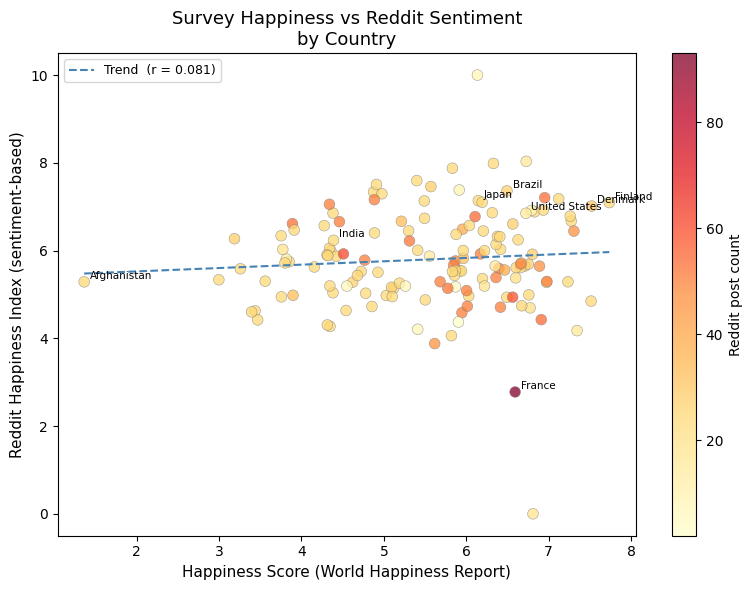


Interpretation:
  r > 0.4  → Reddit discussions align reasonably well with official surveys.
  r ≈ 0    → Reddit is an independent/noisy signal.
  r < 0    → Possible negativity-bias: unhappy people post more.


In [45]:
# --- 8.4 Compare Reddit index with survey-based happiness_score ---

import matplotlib.pyplot as plt

# Merge on country key
df_compare = df_final[["country", "happiness_score"]].merge(
    df_reddit[["country", "reddit_happiness_index", "reddit_post_count"]],
    on="country",
    how="inner"
).dropna(subset=["happiness_score", "reddit_happiness_index"])

corr = df_compare["happiness_score"].corr(df_compare["reddit_happiness_index"])
print(f"Pearson correlation  happiness_score ↔ reddit_happiness_index: r = {corr:.3f}")
print(f"Countries in comparison: {len(df_compare)}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    df_compare["happiness_score"],
    df_compare["reddit_happiness_index"],
    c=df_compare["reddit_post_count"],
    cmap="YlOrRd",
    alpha=0.75,
    edgecolors="grey",
    linewidths=0.4,
    s=60,
)
# Annotate a few notable countries
notable = ["Finland", "Denmark", "Afghanistan", "United States",
           "France", "Japan", "Brazil", "India"]
for _, row in df_compare[df_compare["country"].isin(notable)].iterrows():
    ax.annotate(
        row["country"],
        (row["happiness_score"], row["reddit_happiness_index"]),
        fontsize=7.5,
        xytext=(4, 2),
        textcoords="offset points",
    )
# Best-fit line
m, b = np.polyfit(df_compare["happiness_score"],
                  df_compare["reddit_happiness_index"], 1)
x_line = np.linspace(df_compare["happiness_score"].min(),
                     df_compare["happiness_score"].max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="steelblue", lw=1.5,
        label=f"Trend  (r = {corr:.3f})")
plt.colorbar(sc, ax=ax, label="Reddit post count")
ax.set_xlabel("Happiness Score (World Happiness Report)", fontsize=11)
ax.set_ylabel("Reddit Happiness Index (sentiment-based)", fontsize=11)
ax.set_title("Survey Happiness vs Reddit Sentiment\nby Country", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  r > 0.4  → Reddit discussions align reasonably well with official surveys.")
print("  r ≈ 0    → Reddit is an independent/noisy signal.")
print("  r < 0    → Possible negativity-bias: unhappy people post more.")

In [ ]:
# --- 8.5 Merge reddit_happiness_index into df_final and re-export CSV ---

df_final_v2 = df_final.merge(
    df_reddit[["country", "reddit_post_count",
               "reddit_happiness_raw", "reddit_happiness_index"]],
    on="country",
    how="left",
)

print(f"Shape before merge : {df_final.shape}")
print(f"Shape after  merge : {df_final_v2.shape}")
print(f"\nNew columns added  : reddit_post_count, reddit_happiness_raw, "
      f"reddit_happiness_index")
print(f"Coverage           : "
      f"{df_final_v2['reddit_happiness_index'].notna().sum()} / "
      f"{len(df_final_v2)} countries have a Reddit index")

OUTPUT_PATH_V2 = "happiness_education_dataset.csv"
df_final_v2.to_csv(OUTPUT_PATH_V2, index=False, encoding="utf-8")
print(f"\nExported → {OUTPUT_PATH_V2}")

df_final_v2.head()

Shape before merge : (206, 17)
Shape after  merge : (206, 20)

New columns added  : reddit_post_count, reddit_happiness_raw, reddit_happiness_index
Coverage           : 197 / 206 countries have a Reddit index

Exported → happiness_education_dataset.csv


,country,education_index,rank_happiness,happiness_score,gdp_per_capita_log,social_support,healthy_life_exp,freedom_choices,generosity,corruption_perception,literacy_rate_pct,gov_expenditure_edu_pct_gdp,school_enrollment_secondary_pct,school_enrollment_tertiary_pct,tertiary_attainment_pct,gini_coefficient,pisa_score_avg,reddit_post_count,reddit_happiness_raw,reddit_happiness_index
0,Afghanistan,0.414,147.0,1.364,0.649,0.000,0.155,0.000,0.075,0.135,NaN,4.343190,59.613602,10.854360,NaN,29.4,NaN,25,0.014359,5.286891
1,Albania,0.746,89.0,5.411,1.371,1.122,0.696,0.841,0.103,0.057,NaN,3.091530,96.136877,64.729352,19.73,29.0,360.0,7,-0.146124,4.205578
2,Algeria,0.672,84.0,5.571,1.315,1.363,0.782,0.522,0.057,0.219,NaN,5.610157,101.264893,55.532019,7.60,27.6,NaN,28,0.336618,7.458229
3,Andorra,0.720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.898680,99.508652,62.410694,38.20,NaN,NaN,25,0.141221,6.141669
4,Angola,0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.512737,51.483905,10.049358,2.50,51.3,NaN,25,0.149444,6.197073
